In [29]:
! pip install pandas scikit-learn numpy tensorflow

In [30]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [31]:
boston_ds = fetch_openml(name="boston", version=1, as_frame=True)

df = boston_ds.frame

x = df.drop("MEDV", axis=1)
y = df["MEDV"]

x = x.apply(pd.to_numeric, errors="coerce").fillna(0)

x = StandardScaler().fit_transform(x)
y = y.to_numpy()

In [32]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [33]:
x_train

array([[-0.40992396, -0.48772236, -1.2660231 , ..., -0.30309415,
         0.41057102, -1.09799011],
       [-0.00913688, -0.48772236,  1.2319449 , ..., -1.73641788,
        -2.94572872,  0.33178248],
       [-0.41635358,  0.370669  , -1.13908197, ..., -1.64394538,
         0.33590374, -1.24657432],
       ...,
       [-0.41877066,  2.94584308, -1.3316823 , ..., -0.67298414,
         0.37570436, -0.93398678],
       [ 0.87825441, -0.48772236,  1.01599907, ...,  0.80657583,
        -2.70626713,  1.48821619],
       [-0.39389588, -0.48772236, -0.37597609, ...,  1.13022958,
        -3.13442533, -0.28358043]])

In [34]:
x_train.shape

(379, 13)

In [35]:
from tensorflow import keras
model = keras.Sequential([
    keras.layers.Dense(70, input_shape=(x_train.shape[1],)),
    keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.compile(optimizer="adam", metrics=["mae"], loss="mse")

In [37]:
history = model.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=1)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 628.4991 - mae: 23.0112 - val_loss: 569.9031 - val_mae: 22.3833
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 609.7983 - mae: 22.8404 - val_loss: 557.7736 - val_mae: 22.2619
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 594.3232 - mae: 22.7119 - val_loss: 546.8063 - val_mae: 22.1382
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 579.0972 - mae: 22.5436 - val_loss: 536.8427 - val_mae: 22.0058
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 566.6747 - mae: 22.4068 - val_loss: 526.9549 - val_mae: 21.8609
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 553.1767 - mae: 22.2214 - val_loss: 517.7527 - val_mae: 21.7088
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 541.6585 - mae: 22.0518 - val_loss: 507.9383 - val_mae: 21.5401
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 528.8619 - mae: 21.8445 - val_loss: 498.4817 - val_mae: 21.3626
Epoch 9/10

In [38]:
loss, mae = model.evaluate(x_test, y_test)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 23.4336 - mae: 3.1747
Test MAE: 3.174680709838867


In [39]:
history.history

{'loss': [628.4991455078125,
  609.79833984375,
  594.3231811523438,
  579.09716796875,
  566.6746826171875,
  553.1766967773438,
  541.6585083007812,
  528.8619384765625,
  517.0234375,
  504.411865234375,
  491.4349670410156,
  478.8702697753906,
  465.5067443847656,
  452.030517578125,
  437.80279541015625,
  422.6322326660156,
  407.40234375,
  391.11334228515625,
  374.54620361328125,
  357.5902099609375,
  341.18658447265625,
  324.2033996582031,
  307.34942626953125,
  291.3817138671875,
  274.7623291015625,
  259.1141052246094,
  243.61489868164062,
  228.96554565429688,
  213.42691040039062,
  199.37820434570312,
  185.07518005371094,
  171.86474609375,
  159.23016357421875,
  148.10263061523438,
  135.06036376953125,
  123.88572692871094,
  113.35283660888672,
  103.61876678466797,
  94.24374389648438,
  85.87614440917969,
  78.34703826904297,
  71.18016052246094,
  64.94093322753906,
  58.992549896240234,
  53.87118911743164,
  49.02184295654297,
  44.92805480957031,
  41.36

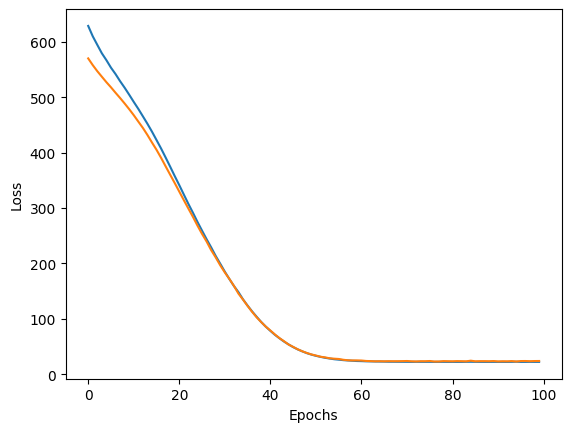

In [43]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Traning Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()
